In [76]:
# importing essential Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn
import seaborn as sns 

## Loading dataset

In [36]:
from sklearn.datasets import load_breast_cancer
cancer  = load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [19]:
df_feature = pd.DataFrame(data=cancer['data'], columns=cancer['feature_names'])
df_feature.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Summary and information over dataset

In [20]:
df_feature.info()
cancer.target_names

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

array(['malignant', 'benign'], dtype='<U9')

# Support Vector Machine

## Splitting dataset into Train and Test

In [38]:
from sklearn.model_selection import train_test_split
X = df_feature
y = pd.Series(cancer["target"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### scalling to avoid Negative

In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Fitting data into algorithm

In [47]:
from sklearn.svm import SVC
svm_model = SVC( probability=True, random_state=42)
# Fit the model to the training data
svm_model.fit(X_train_scaled, y_train) 

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
# Model prediction
svm_predictions = svm_model.predict(X_test_scaled)

### Creating Confusion Matrix of SVM

In [61]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, svm_predictions, labels=svm_model.classes_)
print("Confusion matrix:\n")
print(cm)
print('/n')
print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions))

Confusion matrix:

[[ 62   4]
 [  1 104]]
/n

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        66
           1       0.96      0.99      0.98       105

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



[]

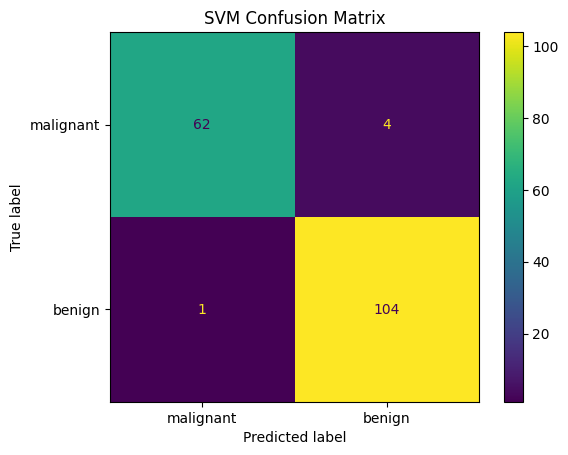

In [82]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
#ConfusionMatrixDisplay(model, )

disp = ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=cancer.target_names)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.plot()

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("SVM Results")

print("Accuracy: %.3f" % accuracy_score(y_test, svm_predictions))
print("Precision: %.3f" % precision_score(y_test, svm_predictions))
print("Recall: %.3f" % recall_score(y_test, svm_predictions))
print("F1-score: %.3f" % f1_score(y_test, svm_predictions))


SVM Results
Accuracy: 0.971
Precision: 0.963
Recall: 0.990
F1-score: 0.977


# Chi-square Feature selection

In [74]:
from sklearn.feature_selection import chi2, SelectKBest
k = 10

chi2_selector = SelectKBest(score_func=chi2, k=k)

X_train_chi2 = chi2_selector.fit_transform(X_train_scaled, y_train)
X_test_chi2 = chi2_selector.transform(X_test_scaled)

In [ ]:
selected_mask = chi2_selector.get_support()
selected_features = X.columns[selected_mask]

chi2_scores = chi2_selector.scores_[selected_mask]

feature_scores = pd.DataFrame({'Feature': selected_features, 'Chi2 Score': chi2_scores})

feature_scores = feature_scores.sort_values( by='Chi2 Score', ascending=False)

print(feature_scores)

                Feature  Chi2 Score
4   mean concave points   38.411529
9  worst concave points   35.302818
3        mean concavity   33.491312
7            worst area   25.665044
6       worst perimeter   25.112159
5          worst radius   25.042491
8       worst concavity   23.583837
2             mean area   21.456747
1        mean perimeter   19.768365
0           mean radius   19.018236


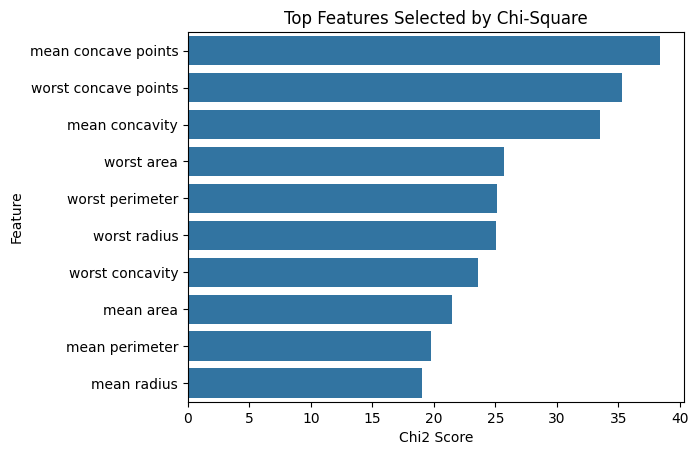

In [92]:

plt.figure()

sns.barplot( x='Chi2 Score', y='Feature', data=feature_scores)

plt.title('Top Features Selected by Chi-Square')
plt.show()

In [78]:
svm_chi2_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_chi2_model.fit(X_train_chi2, y_train)

chi2_predictions = svm_chi2_model.predict(X_test_chi2)

In [ ]:
print("SVM & Chi2 Results")

print("Accuracy: %.3f" % accuracy_score(y_test, chi2_predictions))
print("Precision: %.3f" % precision_score(y_test, chi2_predictions))
print("Recall: %.3f" % recall_score(y_test, chi2_predictions))
print("F1-score: %.3f" % f1_score(y_test, chi2_predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, chi2_predictions))

 SVM & Chi2 Results
Accuracy: 0.947
Precision: 0.944
Recall: 0.971
F1-score: 0.958

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        66
           1       0.94      0.97      0.96       105

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



<Figure size 640x480 with 0 Axes>

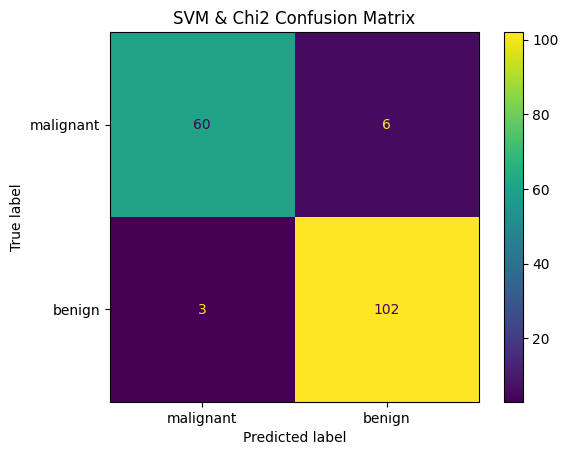

In [93]:
cm_chi2 = confusion_matrix(y_test, chi2_predictions)

plt.figure()

disp = ConfusionMatrixDisplay( confusion_matrix=cm_chi2, display_labels=cancer.target_names)

disp.plot()
plt.title("SVM & Chi2 Confusion Matrix")
plt.show()

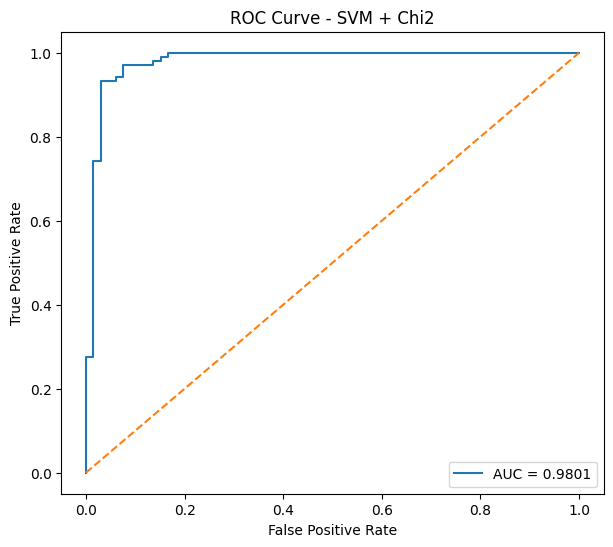

In [90]:
from sklearn.metrics import roc_curve , auc
probabilities = svm_chi2_model.predict_proba(X_test_chi2)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM + Chi2')
plt.legend()
plt.show()

# Discretization

## Discretization function

In [95]:

def equal_width_discretization(df, bins=5):
    df_discrete = df.copy()

    for column in df.columns:
        df_discrete[column] = pd.cut(
            df[column],
            bins=bins,
            labels=False
        )

    return df_discrete

In [96]:
X_discrete = equal_width_discretization(X, bins=5)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_discrete,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [97]:
chi2_selector_discrete = SelectKBest(score_func=chi2, k=10)

X_train_discrete_selected = chi2_selector_discrete.fit_transform(
    X_train_d,
    y_train_d
)

X_test_discrete_selected = chi2_selector_discrete.transform(X_test_d)

In [98]:
svm_discrete_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_discrete_model.fit(
    X_train_discrete_selected,
    y_train_d
)

pred_discrete = svm_discrete_model.predict(
    X_test_discrete_selected
)

In [103]:
cm = confusion_matrix(y_test_d, pred_discrete)
print("Confusion matrix:\n")
print(cm)

Confusion matrix:

[[ 58   6]
 [  5 102]]


In [105]:
print("Discretized Data & Chi2 & SVM ")

print("Accuracy: %.3f" % accuracy_score(y_test_d, pred_discrete))
print("Precision: %.3f" % precision_score(y_test_d, pred_discrete))
print("Recall: %.3f" % recall_score(y_test_d, pred_discrete))
print("F1-score: %.3f" % f1_score(y_test_d, pred_discrete))

print(classification_report(y_test_d, pred_discrete))

Discretized Data & Chi2 & SVM 
Accuracy: 0.936
Precision: 0.944
Recall: 0.953
F1-score: 0.949
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

